<h1 style='color:#7F3E6E' align='center'>HW1-2 LQR</h1>



This notebook completes the three assignment objectives: derive the lateral vehicle model, implement LQR path tracking on multiple paths, and compare controller behavior for different Q/R tuning choices.

## Objective 1: Vehicle lateral control state-space model

Use the small-angle linear dynamic bicycle model with constant longitudinal speed `v_x`. The model uses lateral velocity `v_y`, yaw rate `r`, and steering input `delta`.

The lateral tire slip angles are approximated by

$$\alpha_f \approx \frac{v_y+l_f r}{v_x}-\delta,\qquad \alpha_r \approx \frac{v_y-l_r r}{v_x}$$

With linear tire forces,

$$F_{yf}=-C_f\alpha_f=C_f\delta-C_f\frac{v_y+l_f r}{v_x}$$

$$F_{yr}=-C_r\alpha_r=-C_r\frac{v_y-l_r r}{v_x}$$

The lateral force and yaw moment balances are

$$m(\dot v_y+v_x r)=F_{yf}+F_{yr}$$

$$I_z\dot r=l_fF_{yf}-l_rF_{yr}$$

Substituting the tire forces gives the dynamic bicycle equations:

$$\dot v_y = -\frac{C_f+C_r}{m v_x}v_y + \left(\frac{C_r l_r - C_f l_f}{m v_x} - v_x\right)r + \frac{C_f}{m}\delta$$

$$\dot r = \frac{C_r l_r - C_f l_f}{I_z v_x}v_y - \frac{C_f l_f^2 + C_r l_r^2}{I_z v_x}r + \frac{C_f l_f}{I_z}\delta$$

For path tracking, augment the dynamic bicycle model with cross-track error and heading error. The signed cross-track error is

$$e = -(x-x_{ref})\sin\theta_p + (y-y_{ref})\cos\theta_p$$

and the heading error is defined as

$$\psi_e = \theta - \theta_p$$

With this sign convention and small-angle assumptions,

$$\dot e = v_x \psi_e + v_y$$

$$\dot \psi_e = r$$

For curved paths, the path-heading rate is handled by curvature feedforward steering; the feedback model above is the local linear tracking model.

Therefore, with state

$$x = [e,\ \psi_e,\ v_y,\ r]^T$$

and input `u = delta`, the continuous-time model is

$$\dot x = A_cx + B_cu$$

where

$$A_c = \begin{bmatrix}0&v_x&1&0\\0&0&0&1\\0&0&-\frac{C_f+C_r}{m v_x}&\frac{C_r l_r-C_f l_f}{m v_x}-v_x\\0&0&\frac{C_r l_r-C_f l_f}{I_z v_x}&-\frac{C_f l_f^2+C_r l_r^2}{I_z v_x}\end{bmatrix},\quad B_c=\begin{bmatrix}0\\0\\\frac{C_f}{m}\\\frac{C_f l_f}{I_z}\end{bmatrix}$$

The model is discretized with forward Euler for the LQR design:

$$A_d = I + A_c\Delta t,\quad B_d = B_c\Delta t$$

The discrete LQR control law is

$$\delta = \delta_{ff} - Kx$$

where `K` is found from the discrete algebraic Riccati equation. The curvature feedforward term

$$\delta_{ff} = \tan^{-1}(L\kappa)$$

helps the vehicle follow curved paths without relying only on feedback.


In [1]:
%matplotlib inline

from LQR_Full_state_first_step import (
    continuous_bicycle_matrices,
    lqr_gain,
    run_all_cases,
    print_gain_table,
    print_metric_table,
    make_plots,
    LQRCase,
    simulate_path,
)

A_c, B_c = continuous_bicycle_matrices()
A_c, B_c


(array([[  0.        ,   5.        ,   1.        ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   1.        ],
        [  0.        ,   0.        , -21.33333333,  -0.73333333],
        [  0.        ,   0.        ,   2.84444444, -28.44444444]]),
 array([[ 0.        ],
        [ 0.        ],
        [53.33333333],
        [42.66666667]]))

## Objective 2: LQR path tracking on different reference paths

The implementation tests the LQR tracker on three reference paths: a polynomial plus sinusoid, a sine path, and a lane-change path. To keep this objective focused on path tracking, the baseline `Balanced` tuning is used here. The separate Q/R tuning comparison is shown in Objective 3.

For each time step the simulation finds the nearest path point, computes signed cross-track and heading errors, applies the LQR steering command with curvature feedforward and steering saturation, and propagates the nonlinear vehicle position using the dynamic bicycle lateral states.


In [2]:
paths, cases, results = run_all_cases()

balanced_case = next(case for case in cases if case.name == "Balanced")

print("Balanced LQR path-tracking metrics")
print("path                 rms e   rms psi   max steer   mean |steer rate|")
print("-------------------  ------  --------  ----------  -----------------")
for path_name in paths:
    result = results[(path_name, balanced_case.name)]
    print(
        f"{path_name:19s}"
        f" {result['rms_e']:7.3f}"
        f" {result['rms_psi_deg']:9.3f}"
        f" {result['max_abs_steer_deg']:11.3f}"
        f" {result['mean_abs_steer_rate_deg_s']:18.3f}"
    )


Balanced LQR path-tracking metrics
path                 rms e   rms psi   max steer   mean |steer rate|
-------------------  ------  --------  ----------  -----------------
Polynomial + sine     0.082     3.684      18.867             27.988
Sine                  0.114     5.284      25.082             44.647
Lane change           0.052     2.050      18.137             15.562


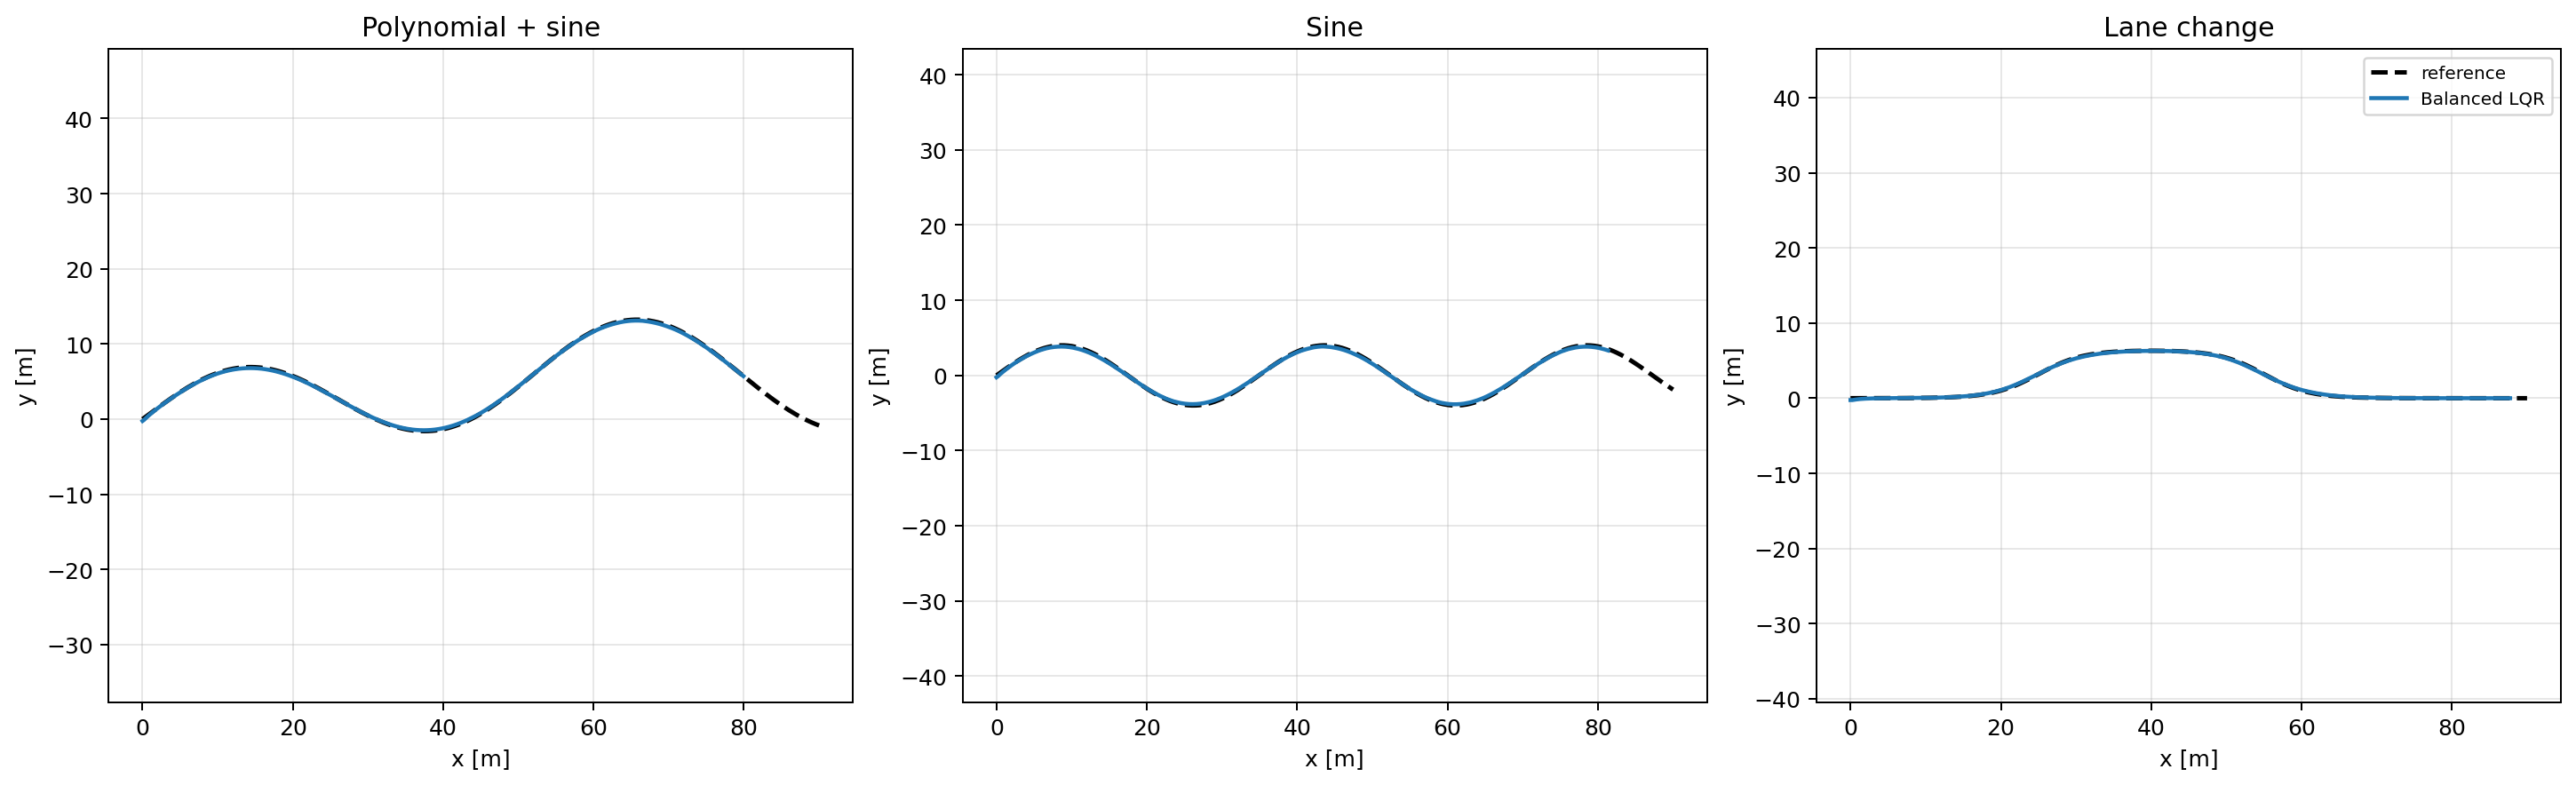

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (path_name, path) in zip(axes, paths.items()):
    ax.plot(path["x"], path["y"], "k--", linewidth=2, label="reference")
    result = results[(path_name, "Balanced")]
    ax.plot(result["x"], result["y"], linewidth=1.8, label="Balanced LQR")
    ax.set_title(path_name)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
axes[-1].legend(loc="best", fontsize=8)
plt.show()


### Interactive LQR simulation

The cell below makes the simulation interactive in Jupyter. The sliders change the main `Q` penalties and `R`, while the dropdown selects the reference path. Re-running the cell displays a live plot and metrics for the selected tuning.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from LQR_Full_state_first_step import LQRCase, run_all_cases, simulate_path

try:
    paths
    cases
    results
except NameError:
    paths, cases, results = run_all_cases()

try:
    import ipywidgets as widgets
except ImportError:
    print("Install ipywidgets from requirements.txt to use the interactive simulation.")
else:
    path_dropdown = widgets.Dropdown(options=list(paths.keys()), value="Lane change", description="Path")
    q_e = widgets.FloatLogSlider(value=30.0, base=10, min=0, max=3, step=0.05, description="Q e")
    q_psi = widgets.FloatLogSlider(value=45.0, base=10, min=0, max=3, step=0.05, description="Q psi")
    r_weight = widgets.FloatLogSlider(value=1.0, base=10, min=-1, max=1.2, step=0.05, description="R")

    def run_interactive(path_name, q_e, q_psi, r_weight):
        case = LQRCase("Interactive", (q_e, q_psi, 1.0, 1.0), r_weight)
        result = simulate_path(paths[path_name], case)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
        axes[0].plot(paths[path_name]["x"], paths[path_name]["y"], "k--", label="reference")
        axes[0].plot(result["x"], result["y"], label="vehicle")
        axes[0].axis("equal")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        axes[0].set_title(path_name)
        axes[1].plot(result["t"], result["e"], label="cross-track error [m]")
        axes[1].plot(result["t"], np.rad2deg(result["steer"]), label="steering [deg]")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
        plt.show()
        print(f"RMS e: {result['rms_e']:.3f} m")
        print(f"RMS heading error: {result['rms_psi_deg']:.3f} deg")
        print(f"Max steering: {result['max_abs_steer_deg']:.3f} deg")
        print(f"Mean |steer rate|: {result['mean_abs_steer_rate_deg_s']:.3f} deg/s")

    controls = {
        "path_name": path_dropdown,
        "q_e": q_e,
        "q_psi": q_psi,
        "r_weight": r_weight,
    }
    display(widgets.HBox([path_dropdown, q_e, q_psi, r_weight]))
    display(widgets.interactive_output(run_interactive, controls))


## Objective 3: Q/R tuning observations

The tuning cases below change the diagonal `Q` penalties and scalar `R` penalty to show the expected LQR tradeoffs. The gain table shows how each tuning changes the feedback weights, and the metric table compares tracking error, heading error, steering magnitude, and steering smoothness on every path.

- **Balanced** uses moderate state penalties and gives a reasonable compromise between tracking and steering effort. It does not produce the smallest error, but it avoids the highest steering demands.

- **Aggressive** increases the `e` and `psi_e` penalties while reducing `R`, so tracking improves compared with Balanced. The cost is larger and faster steering: for example, on the sine path the mean absolute steering rate increases from about `44.6 deg/s` for Balanced to about `64.3 deg/s` for Aggressive.

- **Smooth steering** increases `R`, so steering effort is penalized more heavily. This reduces steering activity but allows larger tracking error. It has the lowest steering-rate value on each path, such as `12.6 deg/s` on the lane-change path, but its RMS cross-track error is consistently higher than Balanced.

- **Lateral-error focused** heavily penalizes cross-track error. This produced the best RMS cross-track tracking on all three paths: `0.030 m` for lane change, `0.040 m` for polynomial plus sine, and `0.055 m` for sine. The tradeoff is more aggressive steering, including saturation at `35 deg` on the lane-change path.

- **Heading-error focused** heavily penalizes heading error. This gave the lowest RMS heading error on all three paths, but it also produced the largest RMS cross-track error in each case. This shows that aligning the vehicle heading with the path does not automatically minimize lateral displacement from the path.

Overall, increasing entries in `Q` makes the corresponding state error more expensive, while increasing `R` makes steering more expensive. The best overall choice depends on the design goal: use the lateral-error focused tuning for minimum path error, the heading-error focused tuning for best yaw alignment, the smooth-steering tuning for actuator/passenger comfort, and the balanced tuning when no single metric should dominate.


In [4]:
from LQR_Full_state_first_step import run_all_cases, print_gain_table, print_metric_table

try:
    paths
    cases
    results
except NameError:
    paths, cases, results = run_all_cases()

print_gain_table(cases)
print_metric_table(results, cases)


LQR gains for x = [e, psi_e, v_y, r]^T
case                    k_e      k_psi     k_vy      k_r
--------------------  -------  --------  -------  -------
Balanced                1.265     2.078    0.077    0.001
Aggressive              2.279     2.761    0.125    0.024
Smooth steering         0.876     1.707    0.054    0.009
Lateral-error focused    2.712     2.415    0.141    0.014
Heading-error focused    1.095     2.886    0.074    0.032

Tracking metrics
path                 case                    rms e   rms psi   max steer   mean |steer rate|
-------------------  --------------------  ------  --------  ----------  -----------------
Lane change         Balanced               0.052     2.050      18.137             15.562
Lane change         Aggressive             0.037     2.096      32.659             23.223
Lane change         Smooth steering        0.062     2.070      12.564             12.610
Lane change         Lateral-error focused   0.030     2.168      35.000           

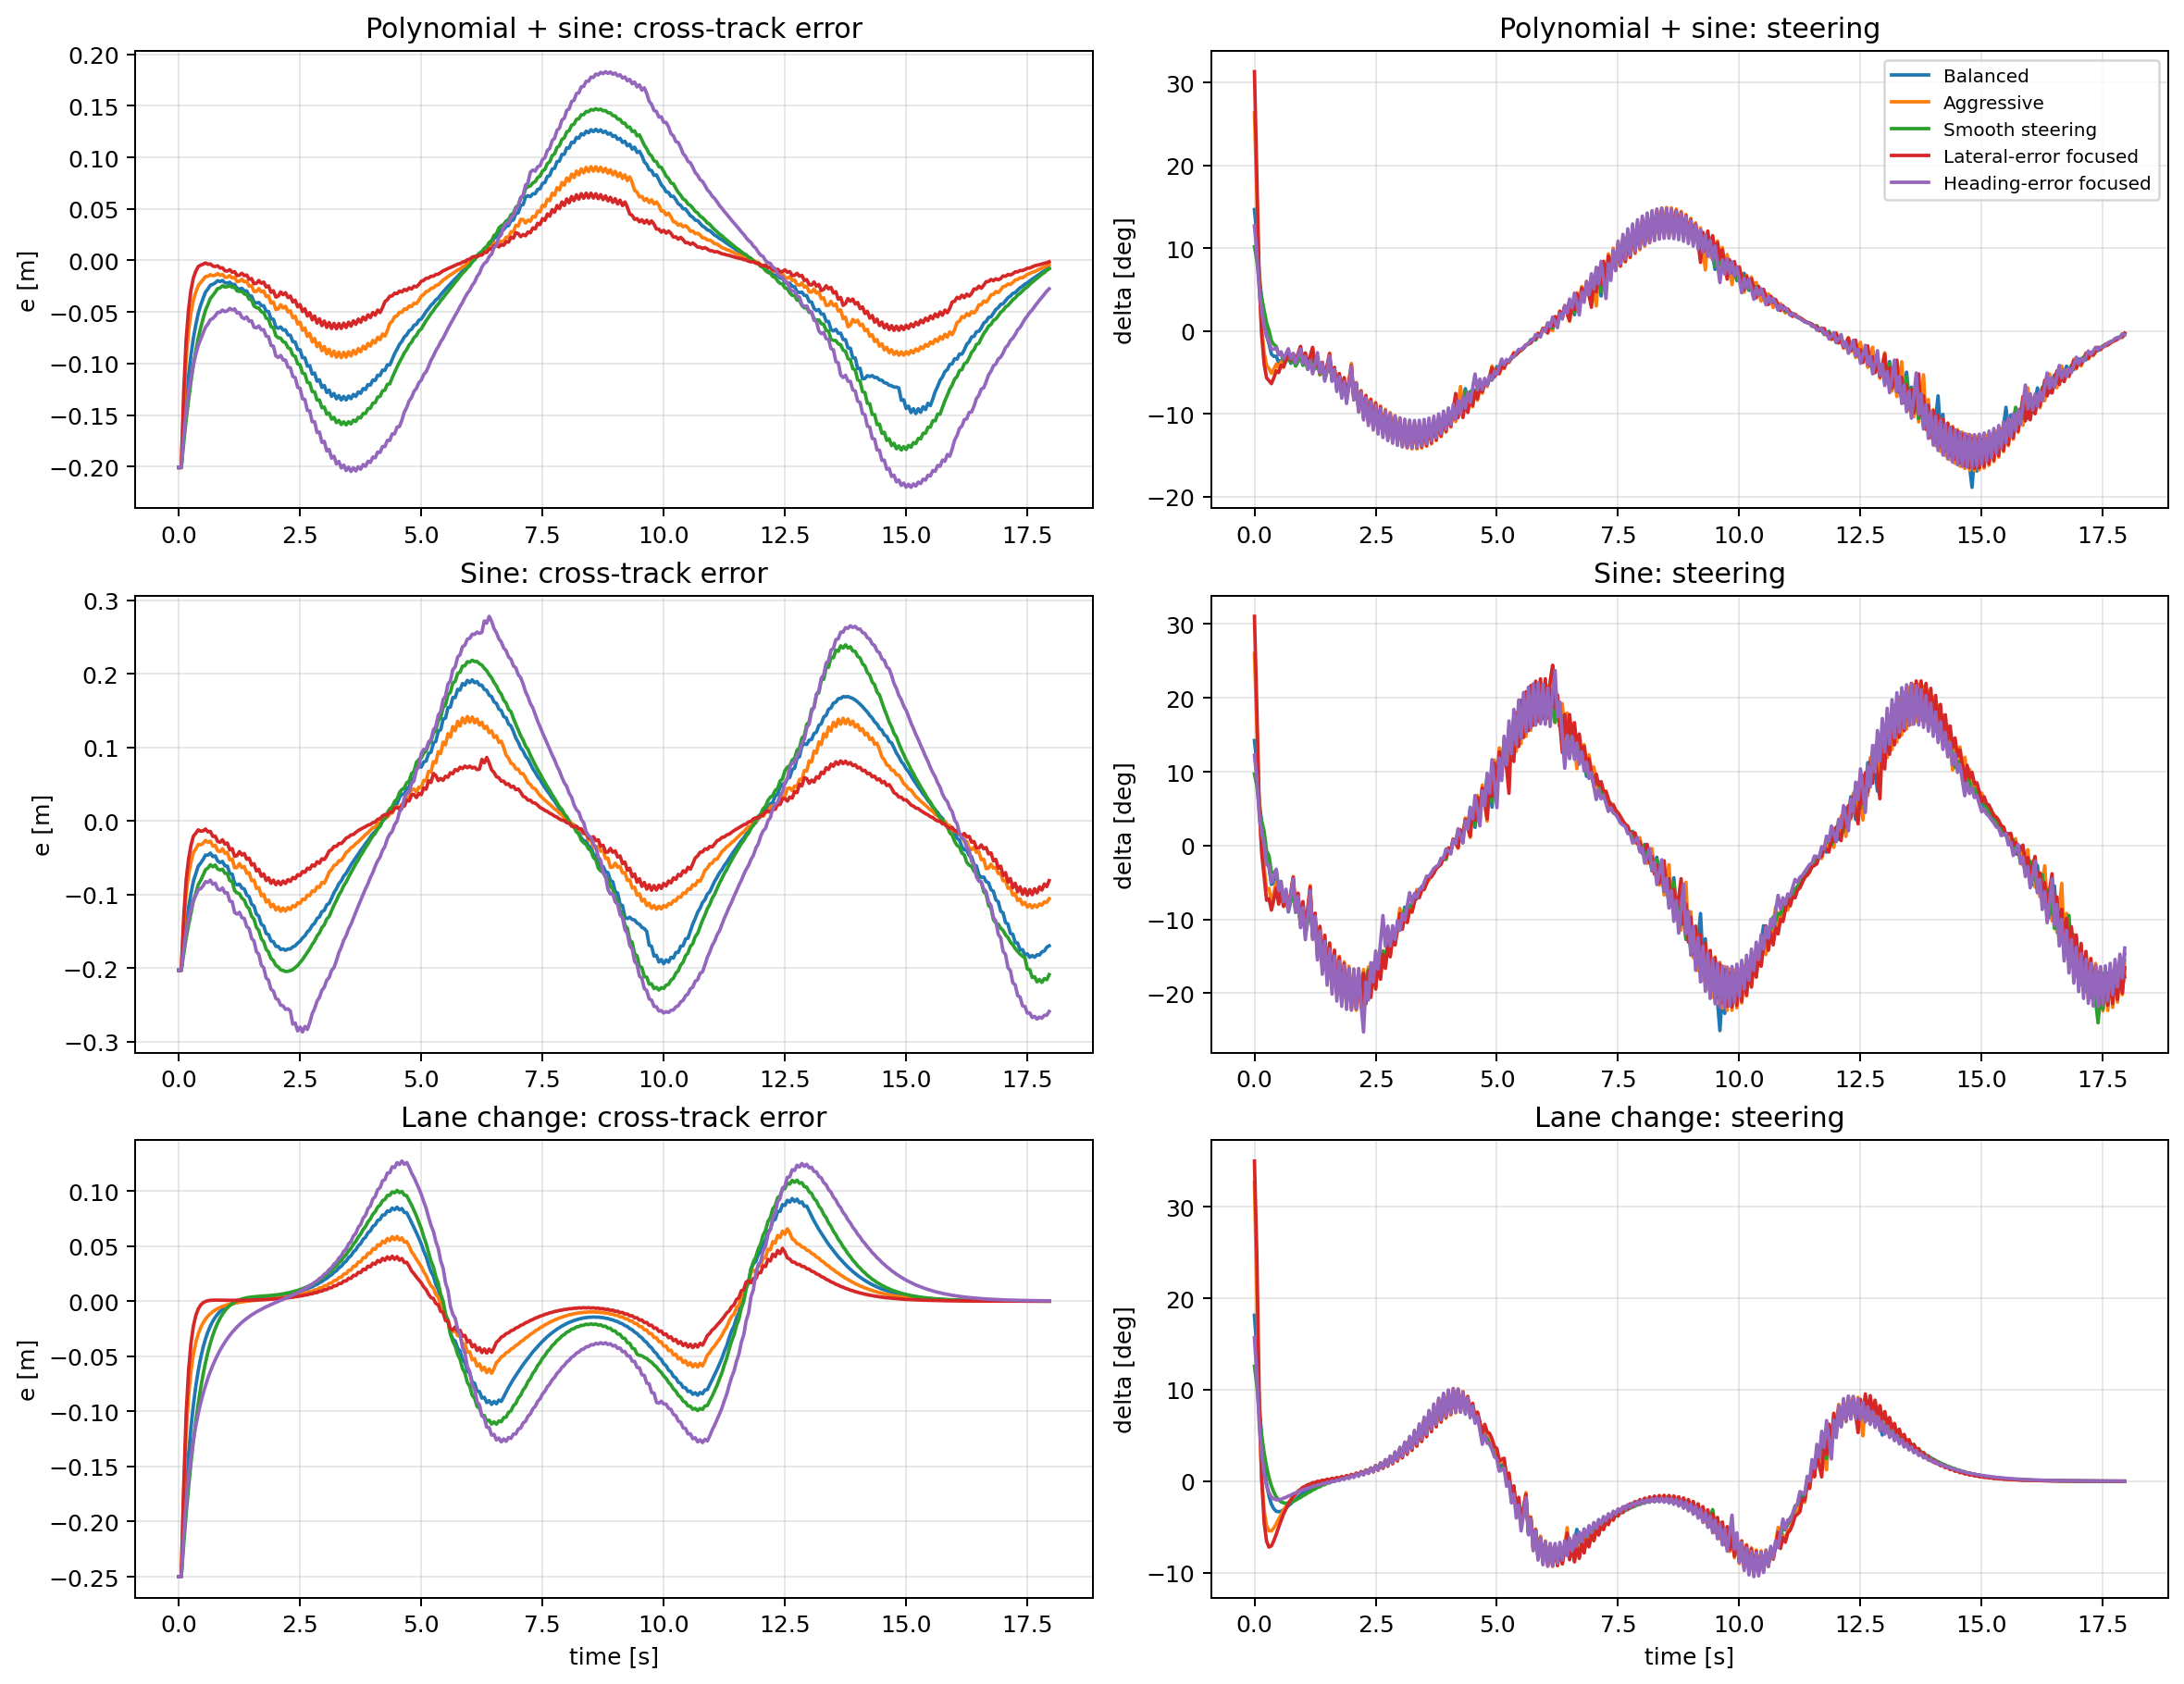

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from LQR_Full_state_first_step import run_all_cases

try:
    paths
    cases
    results
except NameError:
    paths, cases, results = run_all_cases()

fig, axes = plt.subplots(len(paths), 2, figsize=(13, 10), sharex=False, constrained_layout=True)
for row, (path_name, _) in enumerate(paths.items()):
    for case in cases:
        result = results[(path_name, case.name)]
        axes[row, 0].plot(result["t"], result["e"], label=case.name)
        axes[row, 1].plot(result["t"], np.rad2deg(result["steer"]), label=case.name)
    axes[row, 0].set_title(f"{path_name}: cross-track error")
    axes[row, 1].set_title(f"{path_name}: steering")
    axes[row, 0].set_ylabel("e [m]")
    axes[row, 1].set_ylabel("delta [deg]")
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 1].grid(True, alpha=0.3)
axes[-1, 0].set_xlabel("time [s]")
axes[-1, 1].set_xlabel("time [s]")
axes[0, 1].legend(loc="best", fontsize=8)
plt.show()
